# ¿Cuánta electricidad se come la IA?
### Data centers de inteligencia artificial: potencia, energía, localización y un escenario para Argentina

**Trabajo práctico modelo** · Laboratorio de Métodos Cuantitativos Aplicados a la Gestión · Tecnicatura en Gestión y Análisis de Datos en Organizaciones · FCE UBA

Este notebook recorre de punta a punta el análisis que pide el TP grupal: carga y exploración, pregunta de investigación, transformaciones, gráficos y aplicación de un concepto de la materia (derivadas e integrales).

**Fuentes** (todas públicas, se bajan con `python -m src.descarga`):

| Fuente | Qué aporta | Unidad de cruce |
|---|---|---|
| Epoch AI — *AI Data Centers* (sep-2026, CC-BY) | 86 data centers: potencia, cómputo, dueño, dirección, línea de tiempo | nombre del data center |
| Epoch AI — *GPU Clusters* (mar-2026, CC-BY) | 482 clusters en 36 países | país |
| EIA (EE.UU.) | Precio de la electricidad y mix de generación por estado | estado |
| Our World in Data (Ember / IEA) | Demanda eléctrica, gCO₂/kWh por país y % de consumo de data centers | país |

**Uso de IA.** El código y los textos se construyeron con asistencia de Claude (Anthropic). Las celdas marcadas con 🤖 indican el *prompt* utilizado. Todas las cifras fueron verificadas contra los datos.

In [1]:
# Preparación del entorno: funciona igual en Google Colab y en una compu local
import sys
import subprocess
from pathlib import Path

EN_COLAB = "google.colab" in sys.modules
if EN_COLAB:
    if not Path("datacenters-ia").exists():
        subprocess.run(["git", "clone", "https://github.com/Datso653/datacenters-ia.git"], check=True)
    RAIZ = Path("datacenters-ia").resolve()
else:
    RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import carga, transformaciones as tr, costos, graficos

if not (RAIZ / "data/raw/epoch_data_centers/data_centers.csv").exists():
    from src import descarga
    descarga.main()

graficos.aplicar_estilo()
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.2f}".format)

FECHA_CORTE = pd.Timestamp("2026-09-01")   # último mes con datos observados (Epoch actualizó el 11-sep-2026)
FACTOR_USO = 0.8                            # SUPUESTO: fracción del tiempo a plena carga

## 3.1 Carga y exploración inicial

### a) Primeras y últimas filas
La base principal es `data_centers.csv` de Epoch AI: una fila por data center, con su **estado actual**.

In [2]:
dc_crudo = carga.cargar_data_centers()
columnas_vista = ["nombre", "pais", "duenio", "mw_it", "h100e", "capex_usd_bn"]
display(dc_crudo[columnas_vista].head())
display(dc_crudo[columnas_vista].tail())

,nombre,pais,duenio,mw_it,h100e,capex_usd_bn
0,Colossus 2,United States,SpaceXAI #confident,946.00,"1,111,672.56",35.84
1,Microsoft Fairwater Atlanta,United States,Microsoft #confident,636.00,"768,768.72",24.09
2,Anthropic-Amazon New Carlisle,United States,Amazon #confident,910.00,"685,912.08",34.47
3,Meta Prometheus,United States,Meta #confident,562.00,"679,568.32",21.29
4,Google Pryor (North),United States,Google #confident,368.00,"636,685.19",13.94


,nombre,pais,duenio,mw_it,h100e,capex_usd_bn
81,OpenAI Stargate Shackelford,United States,Oracle #confident,0.00,0.00,0.00
82,OpenAI Stargate UAE,United Arab Emirates,G42 #likely,0.00,0.00,0.00
83,OpenAI Stargate Wisconsin,United States,Oracle #confident,0.00,0.00,0.00
84,QTS Cedar Rapids,United States,NaN,0.00,0.00,0.00
85,QTS Eagle Mountain,United States,NaN,0.00,0.00,0.00


### b) Estructura: dimensiones, tipos y cobertura

Glosario de las columnas clave:
- **`mw_it`**: potencia de los servidores en megawatts. No incluye refrigeración.
- **`h100e`**: capacidad de cómputo expresada en "chips NVIDIA H100 equivalentes". Permite comparar hardware distinto.
- **`capex_usd_bn`**: costo de capital estimado (miles de millones de USD de 2025).

In [3]:
print("Dimensiones:", dc_crudo.shape)
print()
print(dc_crudo.dtypes)

Dimensiones: (86, 16)

nombre                     object
h100e                     float64
mw_it                     float64
capex_usd_bn              float64
duenio                     object
usuarios                   object
fuentes                    object
Calculations sheet         object
proyecto                   object
Current chip types         object
All chip types             object
Investors                  object
Construction companies     object
Energy companies           object
pais                       object
direccion                  object
dtype: object


In [4]:
print("Cobertura geográfica (data centers por país):")
print(dc_crudo["pais"].value_counts())

tl = carga.cargar_timelines()
print(f"\nLínea de tiempo: {tl['fecha'].min():%Y-%m-%d} a {tl['fecha'].max():%Y-%m-%d} · "
      f"{tl['nombre'].nunique()} data centers · {len(tl)} hitos de obra")

Cobertura geográfica (data centers por país):
pais
United States           75
China                    3
Norway                   2
United Kingdom           1
Malaysia                 1
Indonesia                1
Australia                1
Portugal                 1
United Arab Emirates     1
Name: count, dtype: int64

Línea de tiempo: 2018-12-18 a 2030-01-01 · 86 data centers · 499 hitos de obra


### c) Calidad: nulos, duplicados y estadísticas descriptivas

In [5]:
nulos = dc_crudo.isnull().sum().sort_values(ascending=False)
print("Valores nulos por columna:")
print(nulos[nulos > 0])
print("\nFilas duplicadas:", dc_crudo.duplicated().sum(), "| Nombres repetidos:", dc_crudo["nombre"].duplicated().sum())
dc_crudo[["mw_it", "h100e", "capex_usd_bn"]].describe()

Valores nulos por columna:
Construction companies    80
Investors                 77
proyecto                  69
Energy companies          68
usuarios                  22
Current chip types        21
direccion                 12
All chip types            10
duenio                     9
dtype: int64

Filas duplicadas: 0 | Nombres repetidos: 0


,mw_it,h100e,capex_usd_bn
count,86.00,86.00,86.00
mean,154.15,"162,059.90",5.84
std,175.85,"194,096.11",6.66
min,0.00,0.00,0.00
25%,41.25,"40,323.40",1.56
50%,120.00,"120,010.11",4.55
75%,210.25,"200,480.04",7.96
max,946.00,"1,111,672.56",35.84


Antes de modelar, conviene chequear **cómo se construyó** la variable de costo: ¿el costo por MW varía entre data centers?

In [6]:
con_potencia = dc_crudo[dc_crudo["mw_it"] > 0]
capex_por_mw = con_potencia["capex_usd_bn"] * 1000 / con_potencia["mw_it"]
print("Costo de capital por MW (USD millones):")
print(capex_por_mw.describe())

coef = costos.coeficientes_epoch(tl)
print("\nCoeficientes recuperados de la línea de tiempo:", {k: round(v, 3) for k, v in coef.items()})

Costo de capital por MW (USD millones):
count   69.00
mean    37.88
std      0.00
min     37.88
25%     37.88
50%     37.88
75%     37.88
max     37.88
dtype: float64

Coeficientes recuperados de la línea de tiempo: {'capex_usd_m_por_mw': 37.882, 'opex_usd_m_por_mw_anio': 0.902, 'desvio_capex': 0.0, 'desvio_opex': 0.0}


**Hallazgos de la exploración**

- **86 data centers y 16 columnas.** Hay 75 en Estados Unidos; China tiene 3, Noruega 2 y otros seis países uno cada uno. La base es, en la práctica, **una foto de EE.UU.**
- **17 data centers tienen 0 MW.** Todavía están en obra: no es un error, pero hay que separarlos para no distorsionar promedios.
- **Nulos altos en columnas descriptivas**: constructoras, inversores, proyecto y energética. Ninguna es necesaria para la pregunta. La dirección falta en 12 casos y afecta el cruce por estado (se resuelve en 3.3).
- **No hay duplicados.**
- **Hallazgo clave: el costo por MW es idéntico en todos los casos**, con desvío 0. Epoch no *mide* el costo de cada data center: lo **estima** multiplicando la potencia por un coeficiente fijo (37,9 M USD de capital y 0,9 M USD de operación anual por MW). Por eso **no tiene sentido estimar una función de costos** con esta base: una regresión daría R² = 1 por construcción. Esos coeficientes se usan más adelante como **parámetros de un escenario**, no como resultado.
- En cambio, el cómputo por MW (`h100e / mw_it`) sí varía. Es información real sobre la eficiencia del hardware.

## 3.2 Pregunta de investigación

**a) ¿Cuál es la pregunta?**
> ¿Cuánta electricidad demandan los grandes data centers de IA, a qué ritmo crece esa demanda y qué implicaría —en energía, emisiones y costo— instalar uno de 500 MW en Argentina?

**b) ¿Por qué vale la pena responderla?**
La IA suele discutirse como software, pero su insumo crítico es la **electricidad**. En octubre de 2025 OpenAI y Sur Energy firmaron una carta de intención por un data center de hasta 500 MW en la Patagonia (*Stargate Argentina*), por unos USD 25.000 millones y bajo el régimen de incentivos RIGI. Dimensionar ese proyecto frente a la red argentina, sus emisiones y su costo aporta a una discusión de política energética e industrial que hoy se da sin números.

**c) ¿Qué respuesta encontraron?**
*(Se completa al final del notebook, en la sección de conclusiones.)*

## 3.3 Transformaciones y resumen estadístico

### a) Transformaciones justificadas

La función `tr.preparar_data_centers` (en `src/transformaciones.py`) aplica cuatro transformaciones:

1. **Limpiar etiquetas de confianza.** Epoch escribe `"Google #confident"` o `"Meta #likely"`. Sin limpiar, el mismo dueño aparecería como dos categorías distintas en el `groupby`.
2. **Extraer el estado de EE.UU.** a partir de la dirección, con expresiones regulares. Cuando no hay dirección, sale del nombre del proyecto o de sus fuentes. Es la **clave para cruzar con la EIA**.
3. **Filtrar operativos** (`mw_it > 0`). Los que están en obra no consumen electricidad todavía.
4. **Crear `h100e_por_mw`**: cuánto cómputo entra en cada MW, una medida de eficiencia del hardware.

In [7]:
dc = tr.preparar_data_centers(dc_crudo)
operativos = dc[dc["operativo"]]

print(f"Operativos: {len(operativos)} | En obra: {(~dc['operativo']).sum()}")
print("Data centers de EE.UU. sin estado asignado:", dc.query("pais == 'United States'")["estado"].isna().sum())
dc[["nombre", "duenio", "estado", "operativo", "mw_it", "h100e_por_mw"]].head(8)

Operativos: 69 | En obra: 17
Data centers de EE.UU. sin estado asignado: 0


,nombre,duenio,estado,operativo,mw_it,h100e_por_mw
0,Colossus 2,SpaceXAI,TN,True,946.00,"1,175.13"
1,Microsoft Fairwater Atlanta,Microsoft,GA,True,636.00,"1,208.76"
2,Anthropic-Amazon New Carlisle,Amazon,IN,True,910.00,753.75
3,Meta Prometheus,Meta,OH,True,562.00,"1,209.20"
4,Google Pryor (North),Google,OK,True,368.00,"1,730.12"
5,Google New Albany,Google,OH,True,453.00,"1,215.86"
6,OpenAI Stargate Abilene,Oracle,TX,True,421.00,"1,209.85"
7,Microsoft Fairwater Wisconsin,Microsoft,WI,True,369.00,"1,207.80"


5. **Pasar la línea de tiempo a una grilla mensual.** Cada data center informa hitos en fechas distintas: uno en marzo, otro en noviembre. Para sumar la potencia de todos en cada momento, cada uno "arrastra" su último valor conocido (*forward fill*). El resultado es una serie mensual de potencia total.

In [8]:
serie = tr.potencia_en_el_tiempo(tl)
pue = tr.ratio_potencia_total_it(tl)
print(f"PUE mediano (potencia total / potencia IT): {pue:.2f}")
serie[serie["fecha"].dt.month == 1]

PUE mediano (potencia total / potencia IT): 1.30


,fecha,mw_it,n_data_centers
1,2019-01-01,0.00,0
13,2020-01-01,0.00,0
25,2021-01-01,48.00,1
37,2022-01-01,48.00,1
49,2023-01-01,48.00,1
61,2024-01-01,408.00,6
73,2025-01-01,"1,864.00",20
85,2026-01-01,"6,361.63",43
97,2027-01-01,"16,097.13",78
109,2028-01-01,"26,026.13",82


### b) Estadísticos agrupados

**Agrupado 1 — ¿Quién controla la potencia instalada?**

In [9]:
por_duenio = (operativos.groupby("duenio")
              .agg(data_centers=("nombre", "size"),
                   mw_it=("mw_it", "sum"),
                   h100e_millones=("h100e", lambda s: s.sum() / 1e6),
                   h100e_por_mw=("h100e_por_mw", "median"))
              .sort_values("mw_it", ascending=False))
por_duenio["pct_mw"] = por_duenio["mw_it"] / por_duenio["mw_it"].sum() * 100
print(f"Los 5 mayores dueños concentran {por_duenio['pct_mw'].head(5).sum():.1f}% de la potencia operativa")
por_duenio.head(10)

Los 5 mayores dueños concentran 77.3% de la potencia operativa


,data_centers,mw_it,h100e_millones,h100e_por_mw,pct_mw
duenio,,,,,
Google,17,"3,299.00",3.90,"1,215.86",24.88
Meta,14,"2,382.00",2.69,"1,140.92",17.97
Amazon,5,"1,743.00",1.35,753.75,13.15
Microsoft,6,"1,519.00",1.69,988.39,11.46
SpaceXAI,3,"1,303.33",1.40,811.16,9.83
Sin dato,7,983.00,1.03,"1,019.10",7.41
CoreWeave,7,679.00,0.76,"1,208.73",5.12
Oracle,2,493.00,0.59,"1,190.94",3.72
Huawei,1,241.80,0.12,484.83,1.82


**Interpretación.** La potencia está muy concentrada: **Google, Meta, Amazon, Microsoft y SpaceXAI tienen el 77% de los MW operativos**. Hay además diferencias de eficiencia. Google y CoreWeave meten unos 1.200 H100e por MW y Amazon unos 750. Eso refleja qué chips usa cada uno: los chips propios de Amazon (Trainium) rinden menos H100e por MW que los NVIDIA de última generación. Para la pregunta, significa que **la demanda eléctrica depende de muy pocas decisiones de inversión**.

**Agrupado 2 — ¿Dónde se instalan? Cruce con precio y mix eléctrico de la EIA (2024)**

In [10]:
precios_2024 = carga.cargar_eia_precios().query("anio == 2024")
mix_2024 = tr.mix_electrico_por_estado(carga.cargar_eia_generacion(), 2024)

por_estado = (operativos.query("pais == 'United States'")
              .groupby("estado")
              .agg(data_centers=("nombre", "size"), mw_it=("mw_it", "sum"))
              .reset_index()
              .merge(precios_2024, on="estado", how="left")
              .merge(mix_2024, on="estado", how="left")
              .sort_values("mw_it", ascending=False))
print("Estados sin precio o mix tras el cruce:", por_estado[["precio_industrial", "pct_fosil"]].isna().any(axis=1).sum())
por_estado[["estado", "data_centers", "mw_it", "precio_industrial", "pct_fosil", "pct_renovable", "pct_nuclear"]].head(10)

Estados sin precio o mix tras el cruce: 0


,estado,data_centers,mw_it,precio_industrial,pct_fosil,pct_renovable,pct_nuclear
16,OH,5,"1,668.00",7.10,82.11,5.31,12.57
21,TN,3,"1,373.00",6.21,44.71,13.79,42.26
22,TX,9,"1,301.00",6.12,63.81,29.40,6.82
5,IN,2,"1,088.00",8.15,85.16,14.39,0.00
24,VA,7,"1,044.00",8.99,61.51,11.38,28.18
11,NE,4,695.00,7.66,47.76,35.86,16.37
2,GA,3,681.33,7.21,53.66,12.51,34.32
8,MS,2,512.00,6.81,81.94,4.29,13.78
1,AZ,3,449.00,7.90,55.97,16.25,27.91
3,IA,2,427.00,6.80,34.45,65.55,0.00


In [11]:
precio_nacional = precios_2024.set_index("estado").loc["US", "precio_industrial"]
precio_ponderado = np.average(por_estado["precio_industrial"], weights=por_estado["mw_it"])
fosil_ponderado = np.average(por_estado["pct_fosil"], weights=por_estado["mw_it"])

estados = (precios_2024.query("estado != 'US'")
           .merge(por_estado[["estado", "mw_it"]], on="estado", how="left")
           .fillna({"mw_it": 0}))
estados["tiene_dc"] = np.where(estados["mw_it"] > 0, "Con data centers", "Sin data centers")

print(f"Precio industrial promedio EE.UU.:                 {precio_nacional:.2f} ¢/kWh")
print(f"Precio industrial ponderado por MW de data centers: {precio_ponderado:.2f} ¢/kWh")
print(f"% de generación fósil ponderado por MW:             {fosil_ponderado:.1f}%")
estados.groupby("tiene_dc")["precio_industrial"].agg(["count", "median", "mean"])

Precio industrial promedio EE.UU.:                 8.13 ¢/kWh
Precio industrial ponderado por MW de data centers: 7.35 ¢/kWh
% de generación fósil ponderado por MW:             62.1%


,count,median,mean
tiene_dc,,,
Con data centers,27,7.77,7.71
Sin data centers,24,8.72,12.10


**Interpretación.** Los data centers se ubican en **estados con electricidad industrial más barata**. El precio ponderado por potencia es 7,35 ¢/kWh, contra 8,13 del promedio nacional. La mediana es 7,77 en los estados con data centers y 8,72 en los que no tienen. Pero esa electricidad barata es **mayormente fósil**: el 62% ponderado. Ohio, el estado con más potencia, genera el 82% con gas y carbón. Es decir que **buscar costo bajo puede significar más emisiones**, y esa tensión se retoma en el escenario argentino.

### c) Cómo se cruzaron las bases (con SQL — clase 22)

Ninguna fuente sola responde la pregunta: Epoch sabe **dónde** están los data centers, la EIA sabe **cuánto cuesta y de dónde sale** la electricidad en cada estado, y Our World in Data sabe **cuánto contamina y cuánto consume** cada país. Para unirlas hace falta una **clave** en común.

```
 data_centers (Epoch) ──nombre──► timelines (Epoch)          → serie de potencia en el tiempo
        │
        └──estado (extraído de la dirección)──► precios EIA  → precio industrial 2024
                                            └──► mix EIA     → % fósil / renovable / nuclear

 gpu_clusters (Epoch) ──pais (normalizado)──► intensidad OWID → gCO₂/kWh 2024
                                         └──► demanda OWID    → TWh 2024
```

| Cruce | Clave | Tipo | Problema a resolver antes de unir |
|---|---|---|---|
| data centers ↔ línea de tiempo | `nombre` | `LEFT JOIN` | ninguno: mismo proveedor |
| data centers ↔ EIA | `estado` | `LEFT JOIN` | la clave **no existe**: hay que construirla desde la dirección |
| clusters ↔ OWID | `pais` | `LEFT JOIN` | los nombres **no coinciden** ("United States of America" vs "United States") |

Se usa `LEFT JOIN` en todos los casos porque la tabla de la izquierda es la protagonista: no se quiere perder ningún data center aunque le falte el dato de la derecha (quedaría como nulo y se vería).

**Paso 1 — Diagnóstico antes de unir.** 🤖 *Prompt: «¿Cómo verifico qué claves se pierden antes de hacer un merge en pandas?»*

In [12]:
from src import cruces

# ¿Qué pasa si se intenta cruzar clusters con OWID SIN normalizar los nombres de país?
clusters_crudo = carga.cargar_gpu_clusters()
intensidad_2024 = carga.cargar_intensidad_carbono().query("anio == 2024")[["pais", "gco2_kwh"]]
cruces.reporte_cruce(clusters_crudo, intensidad_2024, "pais", ("clusters", "OWID"))

,valor
claves distintas en clusters,36
claves distintas en OWID,220
claves que coinciden,34
% de clusters con pareja,94.40
solo en clusters (ejemplos),"Philippines (the), United States of America"
filas de clusters con clave vacía,16


In [13]:
# Después de normalizar: el cruce queda completo
clusters_norm = clusters_crudo.assign(pais=tr.normalizar_pais(clusters_crudo["pais"]))
display(cruces.reporte_cruce(clusters_norm, intensidad_2024, "pais", ("clusters", "OWID")))

# Y el cruce por estado: data centers de EE.UU. contra la tabla de precios de la EIA
dc_eeuu = dc.query("pais == 'United States'")
display(cruces.reporte_cruce(dc_eeuu, precios_2024, "estado", ("data centers EE.UU.", "EIA")))

,valor
claves distintas en clusters,36
claves distintas en OWID,220
claves que coinciden,36
% de clusters con pareja,100.00
solo en clusters (ejemplos),—
filas de clusters con clave vacía,16


,valor
claves distintas en data centers EE.UU.,29
claves distintas en EIA,52
claves que coinciden,29
% de data centers EE.UU. con pareja,100.00
solo en data centers EE.UU. (ejemplos),—
filas de data centers EE.UU. con clave vacía,0


**Lectura.** Sin normalizar, el país con **más potencia de la base (EE.UU.) quedaba afuera del cruce**, y el error no avisa: el merge simplemente devuelve nulos. Es la trampa más común al unir tablas de fuentes distintas: 34 de 36 países coincidían (94,4%) y los dos que faltaban eran justo EE.UU. y Filipinas. Tras normalizar, coinciden los 36. Hay además **16 clusters sin país**, en su mayoría sistemas chinos que Epoch anonimiza: no son un error del cruce sino un dato ausente en origen. En el cruce por estado, los 29 estados con data centers encuentran su pareja en la EIA (100%).

**Paso 2 — Las mismas uniones en SQL.** Se cargan las tablas en una base `sqlite3` en memoria, igual que en la clase 22, y se escribe cada cruce como `JOIN`.

In [14]:
demanda_2024_tabla = carga.cargar_demanda_electrica().query("anio == 2024")[["pais", "demanda_twh"]]

con = cruces.crear_base({
    "data_centers":    dc[["nombre", "pais", "estado", "duenio", "operativo", "mw_it", "h100e"]],
    "timelines":       tl[["nombre", "fecha", "mw_it", "mw_total"]],
    "precios_2024":    precios_2024[["estado", "precio_industrial", "precio_comercial"]],
    "mix_2024":        mix_2024,
    "clusters":        clusters_norm[["nombre", "pais", "mw", "h100e"]],
    "intensidad_2024": intensidad_2024,
    "demanda_2024":    demanda_2024_tabla,
})
print(cruces.CONSULTA_ESTADOS)
estados_sql = cruces.sql(con, cruces.CONSULTA_ESTADOS)
estados_sql.head(8)


SELECT d.estado,
       COUNT(*)             AS data_centers,
       SUM(d.mw_it)         AS mw_it,
       p.precio_industrial,
       m.pct_fosil
FROM data_centers d
LEFT JOIN precios_2024 p ON d.estado = p.estado
LEFT JOIN mix_2024     m ON d.estado = m.estado
WHERE d.pais = 'United States' AND d.operativo = 1
GROUP BY d.estado
ORDER BY mw_it DESC



,estado,data_centers,mw_it,precio_industrial,pct_fosil
0,OH,5,"1,668.00",7.10,82.11
1,TN,3,"1,373.00",6.21,44.71
2,TX,9,"1,301.00",6.12,63.81
3,IN,2,"1,088.00",8.15,85.16
4,VA,7,"1,044.00",8.99,61.51
5,NE,4,695.00,7.66,47.76
6,GA,3,681.33,7.21,53.66
7,MS,2,512.00,6.81,81.94


In [15]:
# Verificación: ¿SQL y pandas dan exactamente lo mismo?
comparar = ["estado", "data_centers", "mw_it", "precio_industrial", "pct_fosil"]
iguales = np.allclose(
    estados_sql.sort_values("estado")[comparar[1:]].to_numpy(dtype=float),
    por_estado.sort_values("estado")[comparar[1:]].to_numpy(dtype=float))
print("¿El JOIN de SQL coincide con el merge de pandas?", iguales)

print(cruces.CONSULTA_TIMELINE)
display(cruces.sql(con, cruces.CONSULTA_TIMELINE))

¿El JOIN de SQL coincide con el merge de pandas? True

SELECT COUNT(DISTINCT t.nombre)                                AS data_centers_en_timeline,
       COUNT(DISTINCT CASE WHEN d.nombre IS NULL THEN t.nombre END) AS sin_pareja
FROM timelines t
LEFT JOIN data_centers d ON t.nombre = d.nombre



,data_centers_en_timeline,sin_pareja
0,86,0


In [16]:
print(cruces.CONSULTA_PAISES)
display(cruces.sql(con, cruces.CONSULTA_PAISES).head(8))

print("Anti-join (países sin intensidad de carbono):")
cruces.sql(con, cruces.CONSULTA_PAISES_SIN_PAREJA)


SELECT c.pais,
       COUNT(*)       AS clusters,
       SUM(c.mw)      AS mw,
       i.gco2_kwh,
       dm.demanda_twh
FROM clusters c
LEFT JOIN intensidad_2024 i  ON c.pais = i.pais
LEFT JOIN demanda_2024    dm ON c.pais = dm.pais
WHERE c.pais IS NOT NULL
GROUP BY c.pais
ORDER BY mw DESC



,pais,clusters,mw,gco2_kwh,demanda_twh
0,United States,119,"1,962.75",383.78,"4,404.83"
1,China,188,296.90,555.40,"10,069.88"
2,Japan,25,43.10,483.43,"1,016.39"
3,Italy,9,39.94,281.40,318.56
4,France,14,33.18,40.48,471.80
5,Norway,3,29.22,29.66,138.67
6,Switzerland,4,26.78,34.58,63.97
7,Finland,4,25.97,66.63,85.73


Anti-join (países sin intensidad de carbono):


,pais


**Diccionario SQL ↔ pandas usado en este trabajo**

| SQL | pandas |
|---|---|
| `LEFT JOIN precios_2024 p ON d.estado = p.estado` | `dc.merge(precios_2024, on="estado", how="left")` |
| `WHERE d.operativo = 1` | `dc[dc["operativo"]]` |
| `GROUP BY d.estado` + `SUM(d.mw_it)` | `.groupby("estado").agg(mw_it=("mw_it", "sum"))` |
| `LEFT JOIN ... WHERE i.pais IS NULL` (anti-join) | `merge(..., indicator=True).query("_merge == 'left_only'")` |

## 3.4 Análisis gráfico

### a) Evolución temporal: la potencia instalada

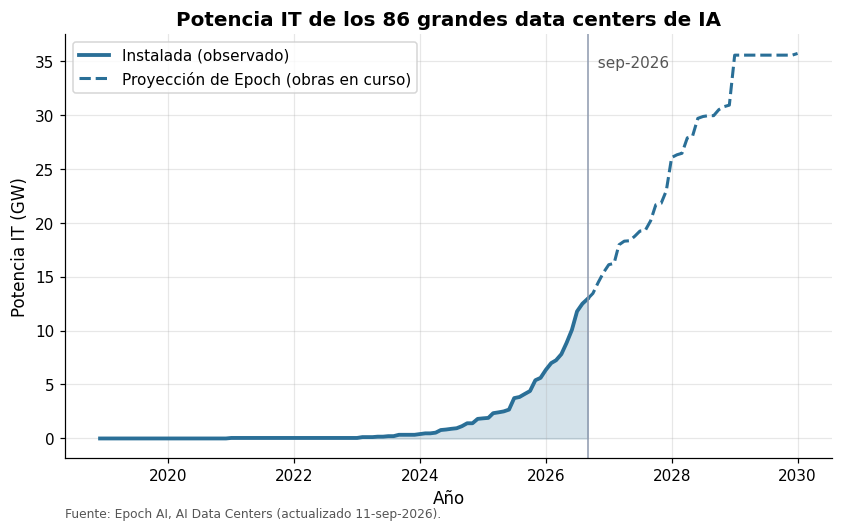

In [17]:
historico = serie[serie["fecha"] <= FECHA_CORTE]
proyectado = serie[serie["fecha"] >= FECHA_CORTE]

fig, ax = plt.subplots()
ax.fill_between(historico["fecha"], historico["mw_it"] / 1000, color=graficos.COLOR_PRINCIPAL, alpha=0.2)
ax.plot(historico["fecha"], historico["mw_it"] / 1000, color=graficos.COLOR_PRINCIPAL, lw=2.5, label="Instalada (observado)")
ax.plot(proyectado["fecha"], proyectado["mw_it"] / 1000, color=graficos.COLOR_PRINCIPAL, lw=2, ls="--", label="Proyección de Epoch (obras en curso)")
ax.axvline(FECHA_CORTE, color=graficos.COLOR_NEUTRO, lw=1)
ax.text(FECHA_CORTE, ax.get_ylim()[1] * 0.92, "  sep-2026", color="#555555")
ax.set(title="Potencia IT de los 86 grandes data centers de IA",
       xlabel="Año", ylabel="Potencia IT (GW)")
ax.legend(loc="upper left")
graficos.nota_fuente(ax, "Fuente: Epoch AI, AI Data Centers (actualizado 11-sep-2026).")
graficos.guardar(fig, "01_potencia_en_el_tiempo")
plt.show()

**Interpretación.** La curva no es lineal: es **explosiva**. En enero de 2024 estos data centers sumaban 0,4 GW, en enero de 2025 1,9 GW y en septiembre de 2026 **12,9 GW**. Si terminan las obras en curso llegarían a **35,5 GW hacia 2029**, casi el triple de hoy. La parte punteada es una **proyección** armada con permisos y avances de obra, no un dato observado. Por eso tiene más incertidumbre.

### b) Comparación entre categorías: potencia por empresa

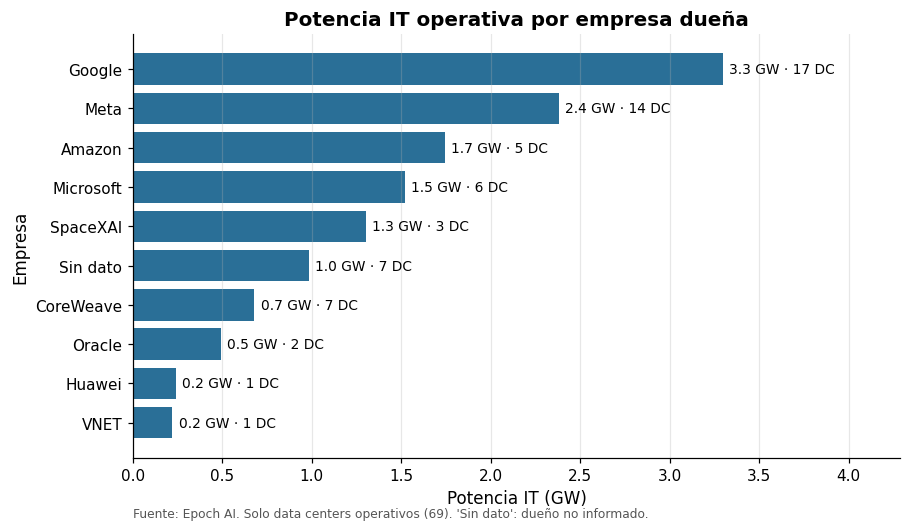

In [18]:
top = por_duenio.head(10).iloc[::-1]
fig, ax = plt.subplots()
barras = ax.barh(top.index, top["mw_it"] / 1000, color=graficos.COLOR_PRINCIPAL)
ax.bar_label(barras, labels=[f"{v/1000:.1f} GW · {n} DC" for v, n in zip(top["mw_it"], top["data_centers"])],
             padding=4, fontsize=9)
ax.set(title="Potencia IT operativa por empresa dueña", xlabel="Potencia IT (GW)", ylabel="Empresa")
ax.set_xlim(0, top["mw_it"].max() / 1000 * 1.3)
ax.grid(axis="y", visible=False)
graficos.nota_fuente(ax, "Fuente: Epoch AI. Solo data centers operativos (69). 'Sin dato': dueño no informado.")
graficos.guardar(fig, "02_potencia_por_empresa")
plt.show()

**Interpretación.** **Google encabeza con 3,3 GW repartidos en 17 data centers**, seguido por Meta (2,4 GW) y Amazon (1,7 GW). El caso de **SpaceXAI** (xAI) muestra otra estrategia: con solo 3 data centers (Colossus) suma 1,3 GW, porque apuesta a pocos sitios gigantes en lugar de muchos medianos. Para un país que quiera atraer inversión, esto implica que **la negociación es con un puñado de empresas** y que cada proyecto individual mueve la aguja de la red eléctrica.

### c) Relación entre dos variables: precio de la electricidad y potencia instalada

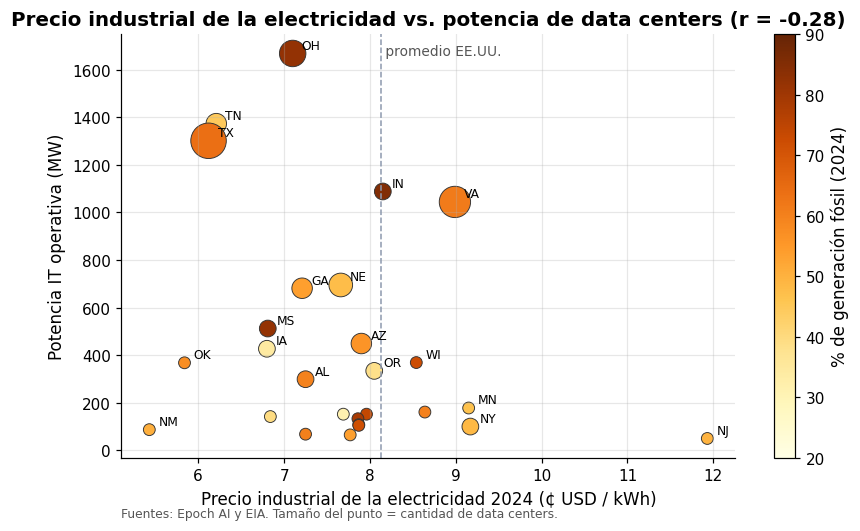

In [19]:
fig, ax = plt.subplots()
puntos = ax.scatter(por_estado["precio_industrial"], por_estado["mw_it"],
                    s=por_estado["data_centers"] * 60, c=por_estado["pct_fosil"],
                    cmap="YlOrBr", vmin=20, vmax=90, edgecolor="#333333", linewidth=0.6)
for _, fila in por_estado.iterrows():
    # se etiquetan solo los estados grandes o extremos en precio, para no encimar textos
    if fila["mw_it"] < 250 and 6 < fila["precio_industrial"] < 9:
        continue
    ax.annotate(fila["estado"], (fila["precio_industrial"], fila["mw_it"]),
                xytext=(6, 3), textcoords="offset points", fontsize=8)
ax.axvline(precio_nacional, color=graficos.COLOR_NEUTRO, ls="--", lw=1)
ax.text(precio_nacional, ax.get_ylim()[1] * 0.95, " promedio EE.UU.", color="#555555", fontsize=9)
fig.colorbar(puntos, ax=ax, label="% de generación fósil (2024)")
correlacion = por_estado[["precio_industrial", "mw_it"]].corr().iloc[0, 1]
ax.set(title=f"Precio industrial de la electricidad vs. potencia de data centers (r = {correlacion:.2f})",
       xlabel="Precio industrial de la electricidad 2024 (¢ USD / kWh)", ylabel="Potencia IT operativa (MW)")
graficos.nota_fuente(ax, "Fuentes: Epoch AI y EIA. Tamaño del punto = cantidad de data centers.")
graficos.guardar(fig, "03_precio_vs_potencia")
plt.show()

**Interpretación.** Casi todos los estados con más potencia (Ohio, Tennessee, Texas, Indiana, Nebraska) están **a la izquierda del promedio nacional**, es decir, con electricidad más barata. La correlación es negativa pero débil (r ≈ −0,28, con solo 27 estados): el precio **importa pero no explica todo**. También pesan la disponibilidad de conexión a la red, la tierra, los incentivos fiscales y la fibra. El color agrega un matiz: los puntos más oscuros, con más generación fósil, se concentran justo donde está la mayor potencia. Una correlación no prueba causalidad; el gráfico **describe** un patrón de localización.

## 3.5 Aplicación de conceptos de la materia: derivadas e integrales

**¿Por qué este concepto y no funciones de costo?** En 3.1 vimos que el costo de Epoch es un múltiplo fijo de la potencia, así que no hay una función de costos para estimar. La variable con información real es la **potencia en el tiempo**, $P(t)$, y sobre ella aplican dos herramientas del cálculo:

- **Derivada** $P'(t)$: a qué velocidad se instala potencia, en GW por año. Dice **cuándo** la red recibe el golpe más fuerte.
- **Integral** $E = \int P(t)\cdot \text{PUE} \cdot u \; dt$: la energía consumida. La potencia (MW) es un *flujo instantáneo*; la energía (MWh) es el **área bajo la curva**. Un data center de 100 MW que opera un año a plena carga consume $100 \times 8760 = 876.000$ MWh.

Supuestos: PUE = 1,30 (mediana de la base, cubre refrigeración y pérdidas) y factor de uso $u$ = 0,8, que es un **supuesto**; más abajo se sensibiliza.

### a) Funciones implementadas (con *docstring*)
🤖 *Prompt: «Escribí funciones en Python, documentadas con docstring, que calculen la derivada numérica de una serie de potencia y su integral acumulada por la regla del trapecio, cuidando las unidades.»*

In [20]:
import inspect
print(inspect.getsource(costos.tasa_de_crecimiento))
print(inspect.getsource(costos.energia_acumulada_twh))
print(inspect.getsource(costos.energia_anual_twh))

def tasa_de_crecimiento(serie: pd.DataFrame, columna: str = "mw_it") -> pd.Series:
    """Derivada numérica de la potencia: MW agregados por año.

    np.gradient usa diferencias centradas: (P[t+1] - P[t-1]) / (2Δt), con Δt en años.
    """
    anios = (serie["fecha"] - serie["fecha"].iloc[0]).dt.days / DIAS_POR_ANIO
    return pd.Series(np.gradient(serie[columna].to_numpy(), anios.to_numpy()), index=serie.index)

def energia_acumulada_twh(serie: pd.DataFrame, pue: float, factor_uso: float,
                          columna: str = "mw_it") -> pd.Series:
    """Integral de la potencia en el tiempo (regla del trapecio), acumulada: TWh consumidos.

    Args:
        serie: DataFrame con 'fecha' y la potencia IT en MW.
        pue: potencia total / potencia IT (refrigeración y pérdidas).
        factor_uso: fracción del tiempo a plena carga (0 a 1). Es un SUPUESTO.
    """
    horas = (serie["fecha"] - serie["fecha"].iloc[0]).dt.days.to_numpy() * 24
    potencia_total = serie[columna].to_n

### b) Aplicación al dataset

In [21]:
# Derivada sobre la serie anual (enero de cada año) para leer "GW agregados por año"
anual = serie[serie["fecha"].dt.month == 1].reset_index(drop=True)
anual["gw_por_anio"] = costos.tasa_de_crecimiento(anual) / 1000

# Integral sobre la serie mensual (más fina = área mejor aproximada)
serie["twh_acumulados"] = costos.energia_acumulada_twh(serie, pue, FACTOR_USO)
anual = anual.merge(serie[["fecha", "twh_acumulados"]], on="fecha")
anual["gw_it"] = anual["mw_it"] / 1000
anual[["fecha", "n_data_centers", "gw_it", "gw_por_anio", "twh_acumulados"]].query("fecha >= '2023-01-01'")

,fecha,n_data_centers,gw_it,gw_por_anio,twh_acumulados
4,2023-01-01,1,0.05,0.18,0.89
5,2024-01-01,6,0.41,0.91,2.97
6,2025-01-01,20,1.86,2.98,12.00
7,2026-01-01,43,6.36,7.12,44.76
8,2027-01-01,78,16.10,9.84,145.63
9,2028-01-01,82,26.03,9.70,324.53
10,2029-01-01,86,35.51,4.80,591.48
11,2030-01-01,86,35.66,0.16,914.91


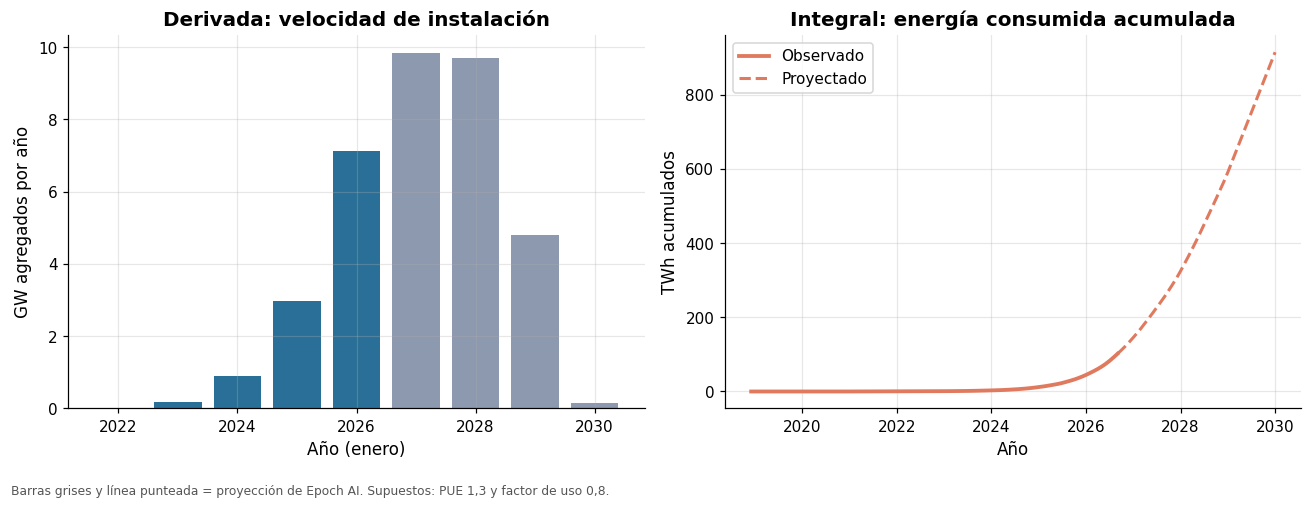

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))

desde_2022 = anual[anual["fecha"] >= "2022-01-01"]
colores = [graficos.COLOR_PRINCIPAL if f <= FECHA_CORTE else graficos.COLOR_NEUTRO for f in desde_2022["fecha"]]
ax1.bar(desde_2022["fecha"].dt.year, desde_2022["gw_por_anio"], color=colores)
ax1.set(title="Derivada: velocidad de instalación", xlabel="Año (enero)", ylabel="GW agregados por año")

ax2.plot(historico["fecha"], serie.loc[historico.index, "twh_acumulados"], color=graficos.COLOR_SECUNDARIO, lw=2.5, label="Observado")
ax2.plot(proyectado["fecha"], serie.loc[proyectado.index, "twh_acumulados"], color=graficos.COLOR_SECUNDARIO, lw=2, ls="--", label="Proyectado")
ax2.set(title="Integral: energía consumida acumulada", xlabel="Año", ylabel="TWh acumulados")
ax2.legend()
graficos.nota_fuente_figura(fig, "Barras grises y línea punteada = proyección de Epoch AI. Supuestos: PUE 1,3 y factor de uso 0,8.")
graficos.guardar(fig, "04_derivada_e_integral")
plt.show()

**Comparación con el consumo eléctrico de países.** Consumo anual de los data centers a su potencia de hoy y a la proyectada, contra la demanda eléctrica total de cada país en 2024:

In [23]:
demanda_2024 = carga.cargar_demanda_electrica().query("anio == 2024").set_index("pais")["demanda_twh"]
mw_hoy = serie.loc[serie["fecha"] == FECHA_CORTE, "mw_it"].iloc[0]
mw_proyectado = serie["mw_it"].iloc[-1]
twh_hoy = costos.energia_anual_twh(mw_hoy, pue, FACTOR_USO)
twh_proyectado = costos.energia_anual_twh(mw_proyectado, pue, FACTOR_USO)

paises = ["Uruguay", "Chile", "Norway", "Argentina", "Canada", "Brazil"]
comparacion = pd.DataFrame({"demanda_2024_twh": demanda_2024[paises]})
comparacion["veces_con_potencia_hoy"] = twh_hoy / comparacion["demanda_2024_twh"]
comparacion["veces_con_potencia_proyectada"] = twh_proyectado / comparacion["demanda_2024_twh"]
print(f"Consumo anual de los data centers: hoy {twh_hoy:,.0f} TWh · proyectado {twh_proyectado:,.0f} TWh")
comparacion

Consumo anual de los data centers: hoy 118 TWh · proyectado 325 TWh


,demanda_2024_twh,veces_con_potencia_hoy,veces_con_potencia_proyectada
pais,,,
Uruguay,14.52,8.12,22.37
Chile,88.62,1.33,3.67
Norway,138.67,0.85,2.34
Argentina,161.68,0.73,2.01
Canada,624.36,0.19,0.52
Brazil,757.31,0.16,0.43


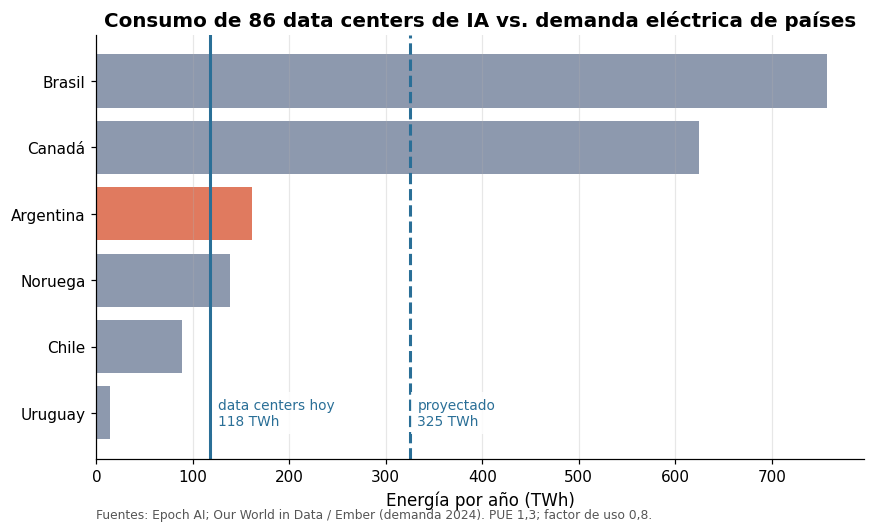

In [24]:
fig, ax = plt.subplots()
orden = comparacion.sort_values("demanda_2024_twh")
nombres = {"Uruguay": "Uruguay", "Chile": "Chile", "Norway": "Noruega", "Argentina": "Argentina",
           "Canada": "Canadá", "Brazil": "Brasil"}
colores = [graficos.COLOR_SECUNDARIO if p == "Argentina" else graficos.COLOR_NEUTRO for p in orden.index]
ax.barh([nombres[p] for p in orden.index], orden["demanda_2024_twh"], color=colores)
ax.axvline(twh_hoy, color=graficos.COLOR_PRINCIPAL, lw=2)
ax.axvline(twh_proyectado, color=graficos.COLOR_PRINCIPAL, lw=2, ls="--")
for x, etiqueta in [(twh_hoy, "data centers hoy"), (twh_proyectado, "proyectado")]:
    ax.text(x + 8, 0, f"{etiqueta}\n{x:,.0f} TWh", color=graficos.COLOR_PRINCIPAL, fontsize=9,
            va="center", bbox=dict(facecolor="white", edgecolor="none", alpha=0.85))
ax.set(title="Consumo de 86 data centers de IA vs. demanda eléctrica de países",
       xlabel="Energía por año (TWh)", ylabel="")
ax.grid(axis="y", visible=False)
graficos.nota_fuente(ax, "Fuentes: Epoch AI; Our World in Data / Ember (demanda 2024). PUE 1,3; factor de uso 0,8.")
graficos.guardar(fig, "05_datacenters_vs_paises")
plt.show()

**Sensibilidad al supuesto de uso.** El factor de uso no se observa, así que se prueba con tres valores:

In [25]:
sensibilidad = pd.DataFrame({"factor_uso": [0.6, 0.8, 1.0]})
sensibilidad["twh_anual_hoy"] = costos.energia_anual_twh(mw_hoy, pue, sensibilidad["factor_uso"])
sensibilidad["pct_demanda_argentina"] = sensibilidad["twh_anual_hoy"] / demanda_2024["Argentina"] * 100
sensibilidad

,factor_uso,twh_anual_hoy,pct_demanda_argentina
0,0.60,88.40,54.68
1,0.80,117.87,72.90
2,1.00,147.34,91.13


### Escenario: *Stargate Argentina* (500 MW)
🤖 *Prompt: «Pensá paso a paso: dado un data center de 500 MW, calculá energía anual, emisiones según la intensidad de carbono de la red de distintos países y costo con los coeficientes de Epoch; explicá qué significa para Argentina.»*

In [26]:
MW_STARGATE_AR = 500   # capacidad anunciada; se asume que es potencia IT

energia_ar = costos.energia_anual_twh(MW_STARGATE_AR, pue, FACTOR_USO)
costo_ar = costos.costo_escenario(MW_STARGATE_AR, anios=10, coef=coef)

intensidad_2024 = carga.cargar_intensidad_carbono().query("anio == 2024").set_index("pais")["gco2_kwh"]
paises_red = ["Norway", "Uruguay", "Brazil", "Canada", "Chile", "Argentina", "United States", "China"]
escenario = pd.DataFrame({"gco2_kwh": intensidad_2024[paises_red]})
escenario["mt_co2_por_anio"] = costos.emisiones_anuales_mt_co2(energia_ar, escenario["gco2_kwh"])

print(f"Energía anual: {energia_ar:.2f} TWh = {energia_ar / demanda_2024['Argentina'] * 100:.1f}% de la demanda eléctrica argentina 2024")
print(f"Capex (coef. Epoch): USD {costo_ar['capex_usd_bn']:.1f} mil M · Opex anual: USD {costo_ar['opex_anual_usd_bn']:.2f} mil M · "
      f"Costo total a 10 años: USD {costo_ar['costo_total_usd_bn']:.1f} mil M")
escenario.sort_values("gco2_kwh")

Energía anual: 4.55 TWh = 2.8% de la demanda eléctrica argentina 2024
Capex (coef. Epoch): USD 18.9 mil M · Opex anual: USD 0.45 mil M · Costo total a 10 años: USD 23.5 mil M


,gco2_kwh,mt_co2_por_anio
pais,,
Norway,29.66,0.14
Uruguay,69.56,0.32
Brazil,106.06,0.48
Canada,185.35,0.84
Chile,259.87,1.18
Argentina,344.83,1.57
United States,383.78,1.75
China,555.40,2.53


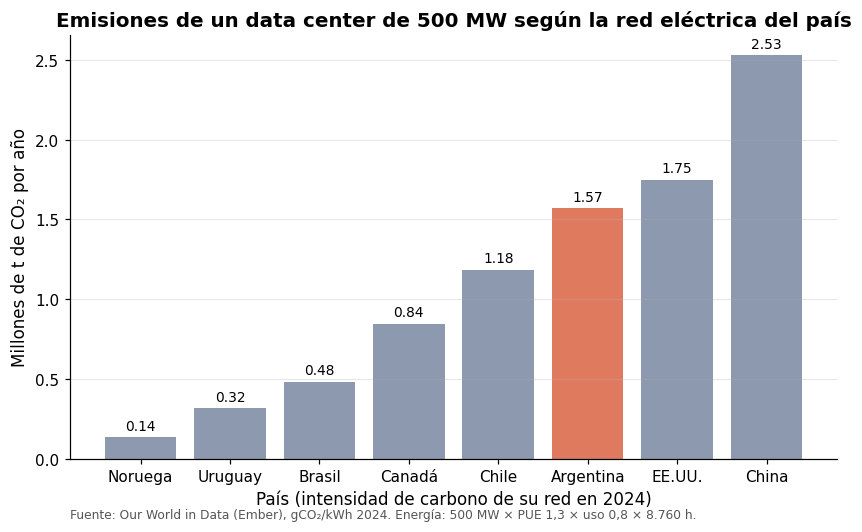

In [27]:
nombres_red = {"Norway": "Noruega", "Uruguay": "Uruguay", "Brazil": "Brasil", "Canada": "Canadá", "Chile": "Chile",
               "Argentina": "Argentina", "United States": "EE.UU.", "China": "China"}
orden = escenario.sort_values("mt_co2_por_anio")
fig, ax = plt.subplots()
colores = [graficos.COLOR_SECUNDARIO if p == "Argentina" else graficos.COLOR_NEUTRO for p in orden.index]
barras = ax.bar([nombres_red[p] for p in orden.index], orden["mt_co2_por_anio"], color=colores)
ax.bar_label(barras, fmt="%.2f", padding=3, fontsize=9)
ax.set(title="Emisiones de un data center de 500 MW según la red eléctrica del país",
       xlabel="País (intensidad de carbono de su red en 2024)", ylabel="Millones de t de CO₂ por año")
ax.grid(axis="x", visible=False)
graficos.nota_fuente(ax, "Fuente: Our World in Data (Ember), gCO₂/kWh 2024. Energía: 500 MW × PUE 1,3 × uso 0,8 × 8.760 h.")
graficos.guardar(fig, "06_emisiones_escenario_500mw")
plt.show()

### c) Interpretación

- **Derivada.** La velocidad de instalación no es constante: **se acelera**. Entre enero de 2025 y enero de 2026 se agregaron 4,5 GW. La derivada centrada pasa de 3 GW por año en 2025 a 7 GW por año en 2026, y las obras en curso la llevan a **casi 10 GW por año en 2027 y 2028**. Después cae porque la base solo incluye proyectos ya conocidos. Para una red eléctrica, lo que importa no es solo *cuánto* sino *qué tan rápido*: una central demora años en construirse y la demanda llega en meses.
- **Integral.** Con la potencia de hoy, estos 86 data centers consumen del orden de **118 TWh por año, el 73% de la demanda eléctrica de toda Argentina**. Con la potencia proyectada, unos **325 TWh: dos Argentinas**. Solo entre enero y septiembre de 2026 consumieron cerca de 57 TWh, casi cuatro veces lo que Uruguay consume en un año entero.
- **Consistencia con la teoría.** Si la potencia fuera constante, la integral sería simplemente $P \times t$. Como $P(t)$ crece, la energía acumulada es **convexa**: la curva se empina, igual que la integral de una función creciente.
- **Sensibilidad.** Aun con un uso de 0,6, el consumo actual equivale a más de la mitad de la demanda argentina. La conclusión cualitativa no depende del supuesto.
- **Stargate Argentina.** Un data center de 500 MW demandaría unos **4,6 TWh por año, el 2,8% de la demanda eléctrica del país**. Es un proyecto grande pero absorbible, *si* hay generación nueva. Con la red promedio argentina emitiría **1,6 Mt de CO₂ al año**, parecido a EE.UU. y 11 veces más que en Noruega. Por eso la clave está en **con qué energía se abastece**: el argumento de la Patagonia es el viento, y con abastecimiento renovable dedicado las emisiones se acercarían al escenario uruguayo o brasileño. El costo con los coeficientes de Epoch, unos USD 19.000 millones de capital, es **del mismo orden de magnitud** que los USD 25.000 millones anunciados.

## 3.6 Extensión: una regresión y un modelo de *machine learning*

Dos modelos sencillos para mostrar la diferencia entre **explicar** y **predecir**:

| | Regresión (econometría) | *Machine learning* |
|---|---|---|
| Pregunta | ¿Cuánto baja por año la energía por unidad de cómputo? | ¿Puedo predecir el cómputo de un data center que no vi? |
| Herramienta | `statsmodels` (MCO) | `scikit-learn` (`LinearRegression`) |
| Qué importa | el **coeficiente** y su intervalo de confianza | el **error en datos nuevos** |

### a) Regresión: la eficiencia energética del cómputo

Modelo: $\ln(\text{kW por H100e}) = a + b \cdot (\text{años desde 2017}) + \varepsilon$. Como la variable está en logaritmo, $(e^{b}-1)\times 100$ es el **cambio porcentual por año**.

In [28]:
from src import modelos

eficiencia = modelos.preparar_eficiencia(clusters_norm)
modelo_ef, resumen_ef = modelos.tendencia_eficiencia(eficiencia)
print(modelo_ef.summary().tables[1])
lo, hi = resumen_ef["ic95_pct_anual"]
print(f"\nCambio anual en kW por H100e: {resumen_ef['cambio_pct_anual']:.1f}% "
      f"(IC 95%: {lo:.1f}% a {hi:.1f}%) · R² = {resumen_ef['r2']:.2f} · n = {resumen_ef['n']} clusters")

                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const                2.9982      0.059     50.710      0.000       2.882       3.114
anios_desde_base    -0.3691      0.012    -32.016      0.000      -0.392      -0.346

Cambio anual en kW por H100e: -30.9% (IC 95%: -32.4% a -29.3%) · R² = 0.73 · n = 404 clusters


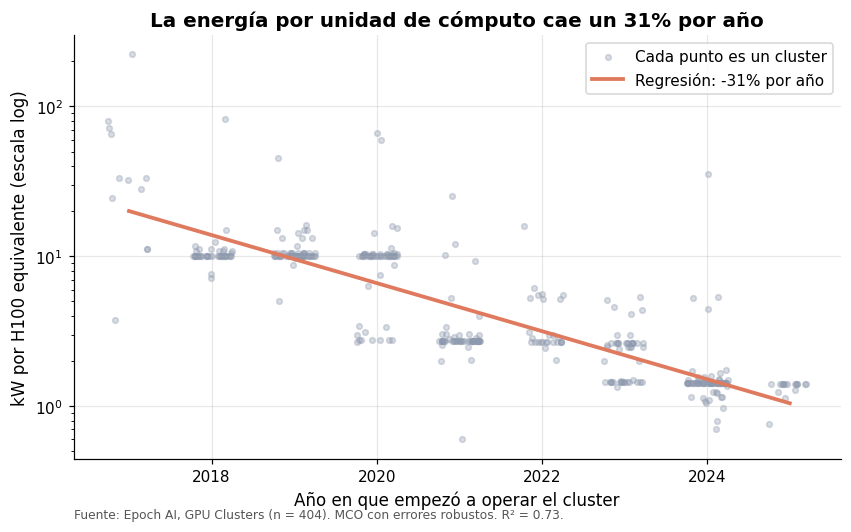

In [29]:
fig, ax = plt.subplots()
ruido = np.random.default_rng(0).uniform(-0.25, 0.25, len(eficiencia))   # separa puntos del mismo año
ax.scatter(eficiencia["anio"] + ruido, eficiencia["kw_por_h100e"], s=14, alpha=0.35, color=graficos.COLOR_NEUTRO,
           label="Cada punto es un cluster")
x = np.linspace(0, 8, 50)
ax.plot(modelos.ANIO_BASE + x, np.exp(modelo_ef.params["const"] + modelo_ef.params["anios_desde_base"] * x),
        color=graficos.COLOR_SECUNDARIO, lw=2.5, label=f"Regresión: {resumen_ef['cambio_pct_anual']:.0f}% por año")
ax.set_yscale("log")
ax.set(title=f"La energía por unidad de cómputo cae un {abs(resumen_ef['cambio_pct_anual']):.0f}% por año",
       xlabel="Año en que empezó a operar el cluster", ylabel="kW por H100 equivalente (escala log)")
ax.legend()
graficos.nota_fuente(ax, f"Fuente: Epoch AI, GPU Clusters (n = {resumen_ef['n']}). MCO con errores robustos. R² = {resumen_ef['r2']:.2f}.")
graficos.guardar(fig, "07_regresion_eficiencia")
plt.show()

**Interpretación.** Cada año, la misma capacidad de cómputo necesita **cerca de un 31% menos de potencia**: los chips nuevos hacen mucho más con cada watt. El intervalo de confianza es estrecho (−32% a −29%) y el año explica el 73% de la variación. ¿Por qué entonces la demanda eléctrica total **sube**? Porque el cómputo instalado crece muchísimo más rápido que lo que mejora la eficiencia. Es la **paradoja de Jevons**: cuando algo se vuelve más eficiente y barato, se usa tanto más que el consumo total aumenta.

*Advertencia:* Epoch estima parte de la potencia a partir de las especificaciones de cada chip, así que la tendencia refleja sobre todo el **recambio de generaciones de hardware**.

### b) *Machine learning*: predecir el cómputo de un data center

Vocabulario:
- **Entrenamiento / prueba:** el modelo aprende con el 70% de los data centers y se evalúa con el 30% que **nunca vio**.
- **R²:** qué parte de la variación explica el modelo (1 = perfecto).
- **MAE (error absoluto medio):** en promedio, por cuántos H100e se equivoca.
- **Modelo tonto:** predice siempre el promedio. Si no le ganamos a eso, el modelo no sirve.

🤖 *Prompt: «Armá un ejemplo mínimo de scikit-learn con train/test split para principiantes, comparando contra un modelo que predice el promedio.»*

In [30]:
datos_ml = modelos.dataset_computo(dc, tl)
resultado = modelos.entrenar_modelo_computo(datos_ml, variables=("mw_it",))

print(f"Data centers: {resultado['n_train']} para entrenar · {resultado['n_test']} para probar")
print(f"Modelo aprendido: H100e ≈ {resultado['modelo'].intercept_:,.0f} + {resultado['coeficientes']['mw_it']:,.0f} × MW")
print(f"R² en datos de prueba:      {resultado['r2_test']:.2f}")
print(f"Error medio del modelo:     {resultado['mae_test']:,.0f} H100e")
print(f"Error medio del modelo tonto: {resultado['mae_tonto']:,.0f} H100e  "
      f"→ el modelo se equivoca {1 - resultado['mae_test'] / resultado['mae_tonto']:.0%} menos")

Data centers: 48 para entrenar · 21 para probar
Modelo aprendido: H100e ≈ 17,021 + 939 × MW
R² en datos de prueba:      0.86
Error medio del modelo:     60,188 H100e
Error medio del modelo tonto: 145,628 H100e  → el modelo se equivoca 59% menos


Un R² de 0,86 parece excelente. Pero ¿qué pasa si el sorteo de qué data centers van a prueba hubiera sido otro?

In [31]:
sorteos = modelos.r2_segun_sorteo(datos_ml, semillas=range(20))
cv = modelos.validacion_cruzada(datos_ml, variables=("mw_it",))
cv_con_anio = modelos.validacion_cruzada(datos_ml, variables=("mw_it", "anio_inicio"))

print(f"R² en 20 sorteos distintos: mínimo {sorteos.min():.2f} · mediana {sorteos.median():.2f} · máximo {sorteos.max():.2f}")
print(f"Validación cruzada (5 pliegues), solo MW:     R² = {cv.mean():.2f} ± {cv.std():.2f}")
print(f"Validación cruzada, MW + año de inicio:       R² = {cv_con_anio.mean():.2f} ± {cv_con_anio.std():.2f}")

prediccion_500 = resultado["modelo"].predict(pd.DataFrame({"mw_it": [MW_STARGATE_AR]}))[0]
print(f"\nPredicción para Stargate Argentina ({MW_STARGATE_AR} MW): ≈ {prediccion_500:,.0f} H100 equivalentes")

R² en 20 sorteos distintos: mínimo 0.20 · mediana 0.76 · máximo 0.95
Validación cruzada (5 pliegues), solo MW:     R² = 0.75 ± 0.15
Validación cruzada, MW + año de inicio:       R² = 0.75 ± 0.14

Predicción para Stargate Argentina (500 MW): ≈ 486,534 H100 equivalentes


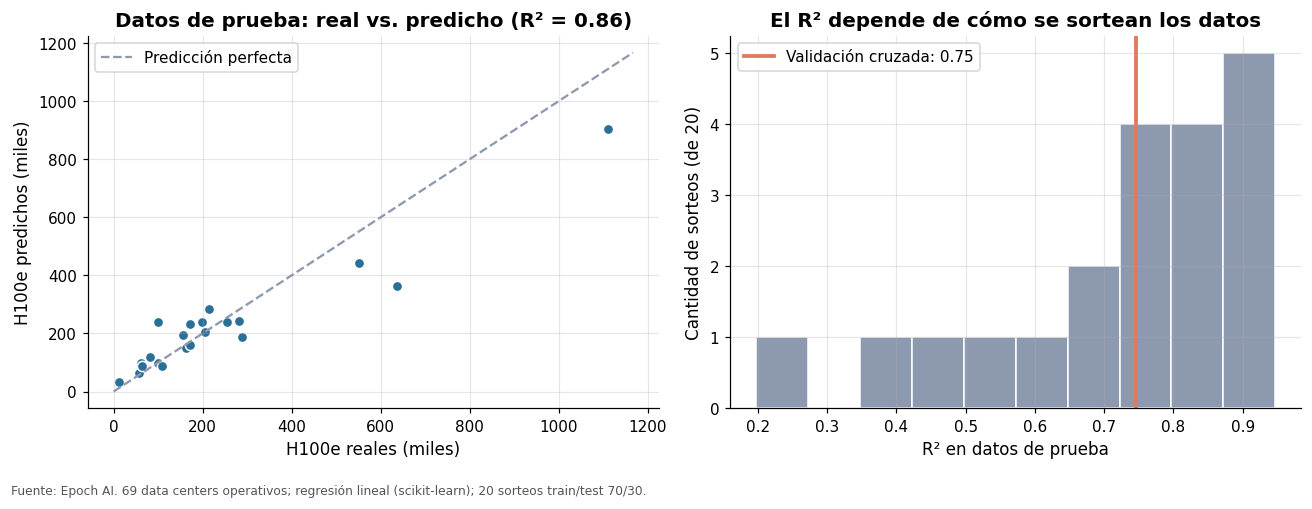

In [32]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
pred = resultado["predicciones"]
tope = max(pred["real"].max(), pred["predicho"].max()) / 1000 * 1.05
ax1.scatter(pred["real"] / 1000, pred["predicho"] / 1000, s=45, color=graficos.COLOR_PRINCIPAL, edgecolor="white")
ax1.plot([0, tope], [0, tope], ls="--", color=graficos.COLOR_NEUTRO, label="Predicción perfecta")
ax1.set(title=f"Datos de prueba: real vs. predicho (R² = {resultado['r2_test']:.2f})",
        xlabel="H100e reales (miles)", ylabel="H100e predichos (miles)")
ax1.legend()

ax2.hist(sorteos, bins=10, color=graficos.COLOR_NEUTRO, edgecolor="white")
ax2.axvline(cv.mean(), color=graficos.COLOR_SECUNDARIO, lw=2.5, label=f"Validación cruzada: {cv.mean():.2f}")
ax2.set(title="El R² depende de cómo se sortean los datos", xlabel="R² en datos de prueba", ylabel="Cantidad de sorteos (de 20)")
ax2.legend()
graficos.nota_fuente_figura(fig, "Fuente: Epoch AI. 69 data centers operativos; regresión lineal (scikit-learn); 20 sorteos train/test 70/30.")
graficos.guardar(fig, "08_machine_learning")
plt.show()

**Interpretación.** El modelo aprende algo razonable: **cada MW aloja unos 940 H100e** y se equivoca un 59% menos que el modelo tonto. Pero la lección más importante es otra: **con solo 69 datos, el R² va de 0,20 a 0,95 según el sorteo**. Reportar solo el 0,86 sería engañoso. La **validación cruzada** (0,75 ± 0,15) es la cifra honesta. Agregar el año de inicio no mejora la predicción, y más variables no siempre significa mejor modelo. Aplicado a Stargate Argentina, 500 MW alojarían del orden de medio millón de H100 equivalentes.

### c) ¿Cuánto se paga de luz?

Se valoriza la energía con dos precios:
- **EE.UU.:** el precio industrial de la EIA ponderado por la potencia de cada estado.
- **Argentina:** el costo monómico proyectado para grandes usuarios en 2026, unos **67 USD/MWh** (proyección de CAMMESA según el informe de Aleph Energy, enero de 2026). Incluye energía, potencia, servicios y transporte.

In [33]:
PRECIO_EEUU_USD_MWH = precio_ponderado * 10   # ¢/kWh → USD/MWh
PRECIO_AR_USD_MWH = 67

gasto = pd.DataFrame({
    "energia_twh": [twh_hoy, twh_proyectado, energia_ar],
    "precio_usd_mwh": [PRECIO_EEUU_USD_MWH, PRECIO_EEUU_USD_MWH, PRECIO_AR_USD_MWH],
}, index=["86 data centers · potencia hoy", "86 data centers · potencia proyectada", "Stargate Argentina (500 MW)"])
gasto["gasto_usd_millones_por_anio"] = costos.gasto_electrico_usd_bn(gasto["energia_twh"], gasto["precio_usd_mwh"]) * 1000
gasto_ar = gasto.loc["Stargate Argentina (500 MW)", "gasto_usd_millones_por_anio"]
print(f"Stargate AR: la electricidad sería el {gasto_ar / (costo_ar['opex_anual_usd_bn'] * 1000):.0%} "
      "del costo operativo anual que asigna Epoch")
gasto

Stargate AR: la electricidad sería el 68% del costo operativo anual que asigna Epoch


,energia_twh,precio_usd_mwh,gasto_usd_millones_por_anio
86 data centers · potencia hoy,117.87,73.49,"8,661.99"
86 data centers · potencia proyectada,324.80,73.49,"23,868.85"
Stargate Argentina (500 MW),4.55,67.00,305.10


**Interpretación.** Los data centers relevados pagan del orden de **USD 8.700 millones de electricidad por año**, y pasarían a unos **USD 23.900 millones** con la potencia proyectada. Un Stargate Argentina de 500 MW gastaría unos **USD 305 millones anuales** en electricidad: cerca de dos tercios de su costo operativo. Para una empresa de IA, **la luz es el principal gasto corriente** después de comprar los chips.

### d) ¿Oligopolio? Concentración del mercado

El **índice de Herfindahl-Hirschman (HHI)** suma los cuadrados de las participaciones de mercado, en %. Va de casi 0 (competencia atomizada) a 10.000 (monopolio). Según las guías de fusiones de EE.UU. (2023), **más de 1.800 es un mercado altamente concentrado**.

In [34]:
con_duenio = por_duenio.drop(index="Sin dato")
participacion = con_duenio["mw_it"] / con_duenio["mw_it"].sum() * 100
hhi = (participacion ** 2).sum()
cr4 = participacion.nlargest(4).sum()
print(f"HHI de la potencia operativa (dueños identificados): {hhi:,.0f}")
print(f"Participación de las 4 mayores (CR4): {cr4:.1f}%")

usuarios = dc["usuarios"].str.split(",").explode().str.strip().value_counts().head(6)
print("\n¿Quién USA los data centers? (cantidad de data centers donde aparece cada laboratorio)")
print(usuarios)

HHI de la potencia operativa (dueños identificados): 1,623
Participación de las 4 mayores (CR4): 72.9%

¿Quién USA los data centers? (cantidad de data centers donde aparece cada laboratorio)
usuarios
OpenAI             20
Meta               16
Google DeepMind    12
Anthropic           8
Microsoft           7
SpaceXAI            2
Name: count, dtype: int64


**Interpretación.** Un HHI de 1.623 con cuatro empresas que reúnen el 73% de la potencia describe un **oligopolio moderado, al borde de la alta concentración**. Del lado de los **usuarios** la concentración es todavía mayor: OpenAI, Meta, Google DeepMind y Anthropic aparecen en la mayoría de los data centers. Las implicancias de manual aplican: poder de negociación frente a gobiernos y empresas eléctricas, barreras de entrada enormes (miles de millones por instalación) y riesgo de que pocas decisiones de inversión muevan la demanda eléctrica de regiones enteras.

## Complemento: ¿y fuera de EE.UU.?

La base de data centers es casi toda estadounidense. Para ver el resto del mundo se usan la base **GPU Clusters** de Epoch (482 clusters, 36 países) y el **% de la electricidad que consumen los data centers** según la IEA.

In [35]:
clusters = carga.cargar_gpu_clusters()
clusters["pais"] = tr.normalizar_pais(clusters["pais"])
por_pais = (clusters.groupby("pais")
            .agg(clusters=("nombre", "size"), mw=("mw", "sum"), h100e_miles=("h100e", lambda s: s.sum() / 1000))
            .sort_values("mw", ascending=False))
por_pais["pct_mw_mundial"] = por_pais["mw"] / por_pais["mw"].sum() * 100
display(por_pais.head(8))

print("Clusters en América Latina:")
display(clusters[clusters["pais"].isin(["Brazil", "Mexico", "Argentina", "Chile"])]
        [["nombre", "pais", "sector", "mw", "h100e"]].sort_values("mw", ascending=False))

,clusters,mw,h100e_miles,pct_mw_mundial
pais,,,,
United States,119,"1,962.75","1,250.99",75.61
China,188,296.90,109.41,11.44
Japan,25,43.10,18.75,1.66
Italy,9,39.94,8.22,1.54
France,14,33.18,18.40,1.28
Norway,3,29.22,20.48,1.13
Switzerland,4,26.78,17.24,1.03
Finland,4,25.97,11.85,1.00


Clusters en América Latina:


,nombre,pais,sector,mw,h100e
148,Petrobras Pegasus (Pégaso),Brazil,Public/Private,1.80,635.67
249,Petrobras Dragão,Brazil,Public/Private,1.66,137.44
298,Petrobras Atlas,Brazil,Public/Private,0.98,68.72
221,Petrobras Gaia,Brazil,Public/Private,0.98,221.98
322,Petrobras Fênix Phase 2,Brazil,Public/Private,0.70,45.48
358,Petrobras Fênix Phase 1,Brazil,Public/Private,0.52,36.38
408,Laboratório Nacional de Computação Científica ...,Brazil,Public,0.25,23.24
445,SENAI CIMATEC Ogbon Cimatec/Petrobras,Brazil,Public,0.21,19.71
304,SiDi IARA,Brazil,Private,0.17,63.06
468,Alibaba Cloud in Mexico,Mexico,Private,NaN,NaN


In [36]:
share = carga.cargar_share_datacenters()
share.pivot_table(index="region", columns="anio", values="share_pct").loc[:, [2020, 2025]].sort_values(2025, ascending=False)

anio,2020,2025
region,,
United States,2.64,4.94
North America (IEA),2.23,4.13
Europe (IEA),1.44,1.87
World,1.01,1.53
China,0.80,1.11
Asia Pacific (IEA),0.72,1.07
World excl. United States and China,0.67,0.86
Middle East (IEA),0.09,0.28
Africa (IEA),0.13,0.25


**Interpretación.** EE.UU. concentra el 76% de la potencia registrada en clusters de GPU. En **América Latina** solo aparecen 9 clusters en Brasil, casi todos supercomputadoras de **Petrobras** de menos de 2 MW cada una, y uno en México. Según la IEA, los data centers usan el **4,9% de la electricidad de EE.UU.** (2025), pero apenas el **0,12% en Centro y Sudamérica**, sin crecimiento desde 2020. Hoy la región está prácticamente **fuera del mapa del cómputo de IA**. Eso le da escala a lo que significaría un proyecto como *Stargate Argentina*: sería, lejos, la mayor instalación de la región.

## Conclusiones

**Respuesta a la pregunta (3.2 c).**
1. **Cuánto:** los 69 data centers de IA operativos de la base suman **12,9 GW** y consumen unos **118 TWh por año**, el 73% de la electricidad de Argentina. Si se completan las obras llegarían a **35,5 GW y unos 325 TWh**.
2. **A qué ritmo:** la derivada muestra una **aceleración**, con cerca de 10 GW por año agregados en 2027-2028. El desafío para las redes es la velocidad, no solo el volumen.
3. **Dónde:** en EE.UU. se localizan en estados con **electricidad industrial más barata** (7,35 contra 8,13 ¢/kWh) pero **mayormente fósil** (62%).
4. **Argentina:** un data center de 500 MW representaría el **2,8% de la demanda eléctrica**, emitiría **1,6 Mt de CO₂ por año con la red promedio** (mucho menos con eólica dedicada) y costaría del orden de **USD 19.000 a 25.000 millones**, más unos **USD 305 millones por año de electricidad**.
5. **Modelos:** la energía por unidad de cómputo cae un **31% por año** (regresión), pero el consumo total sube igual (paradoja de Jevons). El modelo de *machine learning* predice razonablemente el cómputo a partir de los MW (R² de validación cruzada 0,75), y muestra que con pocos datos **un solo sorteo train/test puede engañar**.
6. **Mercado:** oligopolio moderado, con un HHI de 1.623 y 4 empresas con el 73% de la potencia.

**Limitaciones.**
- Epoch **estima**: potencia ±1,4×, cómputo ±1,5× y costo ±1,6× (intervalos del 80%). Además cubre cerca del 46% de la capacidad mundial.
- El **costo** es un coeficiente fijo por MW, así que sirve para escenarios pero no para medir economías de escala.
- El **factor de uso** es un supuesto, aunque la conclusión resiste la sensibilidad.
- La intensidad de carbono es el **promedio de la red** del país; un data center puede contratar energía renovable propia.
- La base de GPU clusters está actualizada a marzo de 2026 y anonimiza los datos de China.
- *Stargate Argentina* es, a la fecha, una **carta de intención** sin sitio ni obra confirmados.

**Extensiones posibles.**
- Sumar los datos de **agua** (`agua_mgd`) cuando mejore la cobertura.
- Cruzar con **precios mayoristas de CAMMESA** para estimar el costo energético en Argentina.
- Estimar **economías de escala** con los costos de hardware de GPU Clusters, controlando por año del chip.

## Registro de uso de IA

| Sección | Uso | Prompt resumido |
|---|---|---|
| 3.1 | Sugerir chequeos de calidad; detectó que el costo por MW era constante | «Actuá como analista de datos senior… señalá limitaciones del dataset» |
| 3.3 | Expresiones regulares para extraer el estado; *forward fill* de la línea de tiempo | «¿Cómo sumo series con fechas distintas en pandas?» |
| 3.5 | Funciones de derivada e integral y verificación de unidades | Ver celdas marcadas con 🤖 |
| Textos | Primer borrador de interpretaciones, revisado y corregido contra los números | «Pensá paso a paso: dado este resultado, explicá qué significa…» |